## Clinical Trial Data Analysis for a New Diabetes Medication

### Scenario
Welcome to your third project in this Python for Data Analysis course. In this section, we want you to imagine that you've just joined the data analysis team at PharmaTech, a leading pharmaceutical company. The company has recently completed a phase III clinical trial for a new type 2 diabetes medication, and they need your expertise to analyze the results.

Your task will be to perform an exploratory data analysis on the clinical trial data to uncover insights that can help determine the efficacy and safety of the new medication.

### Your Mission
Your mission is to conduct a comprehensive analysis of PharmaTech's clinical trial data using Python. You'll need to import the data, clean it, perform statistical analyses, and create visualizations to communicate your findings effectively.

### The Data
You'll be working with the "Diabetes Medication Clinical Trial Dataset" (available in the resources section of this course). This dataset contains information about patient demographics, treatment groups, blood glucose levels, HbA1c levels, adverse events, and other relevant clinical measurements over the 12-month trial period.

Dataset: diabetes_medication_clinical_trial1 3.csv

In [13]:
# Install sklearn
# !pip install scikit-learn

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [ ]:
# Load Data
df = pd.read_csv('diabetes_medication_clinical_trial1_3.csv')

In [16]:
df.head()

,subject_id,group,age,gender,duration_diabetes,initial_hba1c,hba1c,time,adverse_event
0,1,treatment,70,Female,10,8.7,8.7,0,NaN
1,2,placebo,46,Male,19,9.9,9.9,0,Fatigue
2,3,treatment,56,Male,17,8.6,8.6,0,NaN
3,4,treatment,59,Male,19,8.9,8.9,0,Headache
4,5,treatment,68,Male,5,9.1,9.1,0,NaN


In [17]:
df.shape

(1400, 9)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         1400 non-null   int64  
 1   group              1400 non-null   object 
 2   age                1400 non-null   int64  
 3   gender             1400 non-null   object 
 4   duration_diabetes  1400 non-null   int64  
 5   initial_hba1c      1400 non-null   float64
 6   hba1c              1400 non-null   float64
 7   time               1400 non-null   int64  
 8   adverse_event      277 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 98.6+ KB


In [19]:
df.describe()

,subject_id,age,duration_diabetes,initial_hba1c,hba1c,time
count,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000,1400.000000
mean,100.500000,55.250000,10.450000,8.465500,7.686029,12.000000
std,57.754936,9.530602,5.805306,0.869367,1.106412,8.002859
min,1.000000,40.000000,1.000000,7.000000,4.700000,0.000000
25%,50.750000,46.000000,5.000000,7.700000,6.980000,4.000000
50%,100.500000,56.000000,11.000000,8.450000,7.700000,12.000000
75%,150.250000,64.000000,16.000000,9.125000,8.500000,20.000000
max,200.000000,70.000000,20.000000,10.000000,10.000000,24.000000


In [20]:
# Check for missiing values
df_is_null = df.isnull().sum()
print(df_is_null)

subject_id              0
group                   0
age                     0
gender                  0
duration_diabetes       0
initial_hba1c           0
hba1c                   0
time                    0
adverse_event        1123
dtype: int64


In [21]:
df = df.dropna()

In [22]:
df.head()

,subject_id,group,age,gender,duration_diabetes,initial_hba1c,hba1c,time,adverse_event
1,2,placebo,46,Male,19,9.9,9.9,0,Fatigue
3,4,treatment,59,Male,19,8.9,8.9,0,Headache
6,7,treatment,69,Female,12,8.9,8.9,0,Dizziness
7,8,treatment,44,Female,1,8.8,8.8,0,Headache
10,11,treatment,52,Female,2,7.8,7.8,0,Nausea


In [23]:
# Check for missiing values
df_is_null = df.isnull().sum()
print(df_is_null)

subject_id           0
group                0
age                  0
gender               0
duration_diabetes    0
initial_hba1c        0
hba1c                0
time                 0
adverse_event        0
dtype: int64


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 277 entries, 1 to 1399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         277 non-null    int64  
 1   group              277 non-null    object 
 2   age                277 non-null    int64  
 3   gender             277 non-null    object 
 4   duration_diabetes  277 non-null    int64  
 5   initial_hba1c      277 non-null    float64
 6   hba1c              277 non-null    float64
 7   time               277 non-null    int64  
 8   adverse_event      277 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 21.6+ KB


In [25]:
df['time'] = pd.to_numeric(df['time'], errors='coerce')

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 277 entries, 1 to 1399
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   subject_id         277 non-null    int64  
 1   group              277 non-null    object 
 2   age                277 non-null    int64  
 3   gender             277 non-null    object 
 4   duration_diabetes  277 non-null    int64  
 5   initial_hba1c      277 non-null    float64
 6   hba1c              277 non-null    float64
 7   time               277 non-null    int64  
 8   adverse_event      277 non-null    object 
dtypes: float64(2), int64(4), object(3)
memory usage: 21.6+ KB


In [27]:
# Convert 'group' yo categorical
df['group'] = df['group'].astype('category')

In [28]:
df = pd.get_dummies(df, columns=['group'], drop_first=True)

In [29]:
df.rename(columns={'group_treatment':'group_treatment'}, inplace=True)

In [30]:
df.head()

,subject_id,age,gender,duration_diabetes,initial_hba1c,hba1c,time,adverse_event,group_treatment
1,2,46,Male,19,9.9,9.9,0,Fatigue,False
3,4,59,Male,19,8.9,8.9,0,Headache,True
6,7,69,Female,12,8.9,8.9,0,Dizziness,True
7,8,44,Female,1,8.8,8.8,0,Headache,True
10,11,52,Female,2,7.8,7.8,0,Nausea,True


In [31]:
# Convert all columns used in modelling to numeric types
df['group_treatment'] = pd.to_numeric(df['group_treatment'], errors='coerce')

In [32]:
df['hba1c'] = pd.to_numeric(df['hba1c'], errors='coerce')

In [33]:
# Average hba1c value
avg_hba1c_treatment = df[df['group_treatment'] == 1]['hba1c'].mean()
avg_hba1c_treatment

np.float64(7.35985401459854)

In [34]:
# Average placebo value
avg_hba1c_placebo = df[df['group_treatment'] == 0]['hba1c'].mean()
avg_hba1c_placebo

np.float64(8.139142857142858)

In [35]:
print(f"Average HbA1c for Treatment Group: {avg_hba1c_treatment}")
print(f"Average HbA1c for Placebo Group: {avg_hba1c_placebo}")

Average HbA1c for Treatment Group: 7.35985401459854
Average HbA1c for Placebo Group: 8.139142857142858


In [36]:
# Calculate change in HbA1c for each subject

In [37]:
group_hba1c = df.groupby('subject_id')['hba1c']
group_hba1c.head()

1       9.90
3       8.90
6       8.90
7       8.80
10      7.80
        ... 
1376    6.80
1380    5.70
1389    6.98
1394    7.30
1399    4.90
Name: hba1c, Length: 277, dtype: float64

In [38]:
df['hba1c_change'] = df.groupby('subject_id')['hba1c'].transform(lambda x: x - x.iloc[0])

In [39]:
df.head(3)

,subject_id,age,gender,duration_diabetes,initial_hba1c,hba1c,time,adverse_event,group_treatment,hba1c_change
1,2,46,Male,19,9.9,9.9,0,Fatigue,False,0.0
3,4,59,Male,19,8.9,8.9,0,Headache,True,0.0
6,7,69,Female,12,8.9,8.9,0,Dizziness,True,0.0


In [40]:
# Count occurences of each type of adverse event
adverse_events = df['adverse_event'].value_counts()
adverse_events

adverse_event
Fatigue      74
Nausea       71
Headache     68
Dizziness    64
Name: count, dtype: int64

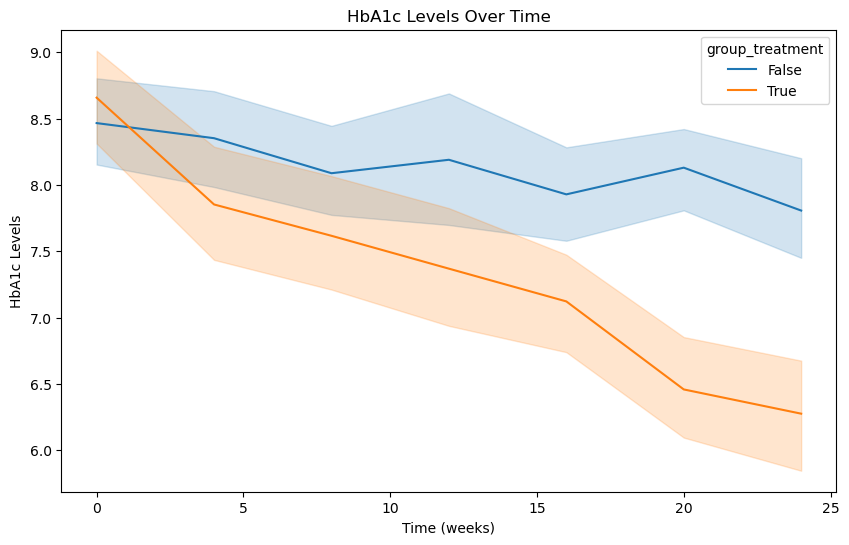

In [41]:
# Plot line graph of hba1c values
plt.figure(figsize=(10, 6))
sns.lineplot(x='time', y='hba1c', hue='group_treatment', data=df)
plt.title('HbA1c Levels Over Time') # set the title
plt.xlabel('Time (weeks)')
plt.ylabel('HbA1c Levels')
plt.show()


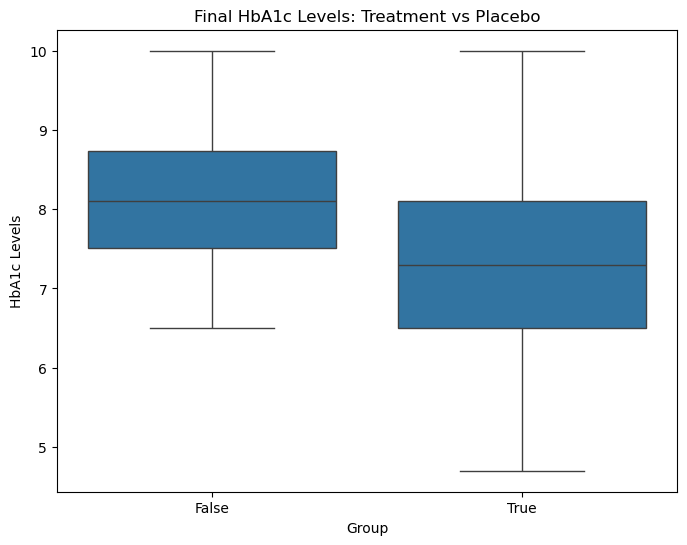

In [42]:
# Plot line graph of hba1c values
plt.figure(figsize=(8, 6))
# sns.lineplot(x='time', y='hba1c', hue='group_treatment', data=df)
sns.boxplot(x='group_treatment', y='hba1c', data=df)
plt.title('Final HbA1c Levels: Treatment vs Placebo') # set the title
plt.xlabel('Group')
plt.ylabel('HbA1c Levels')
plt.show()


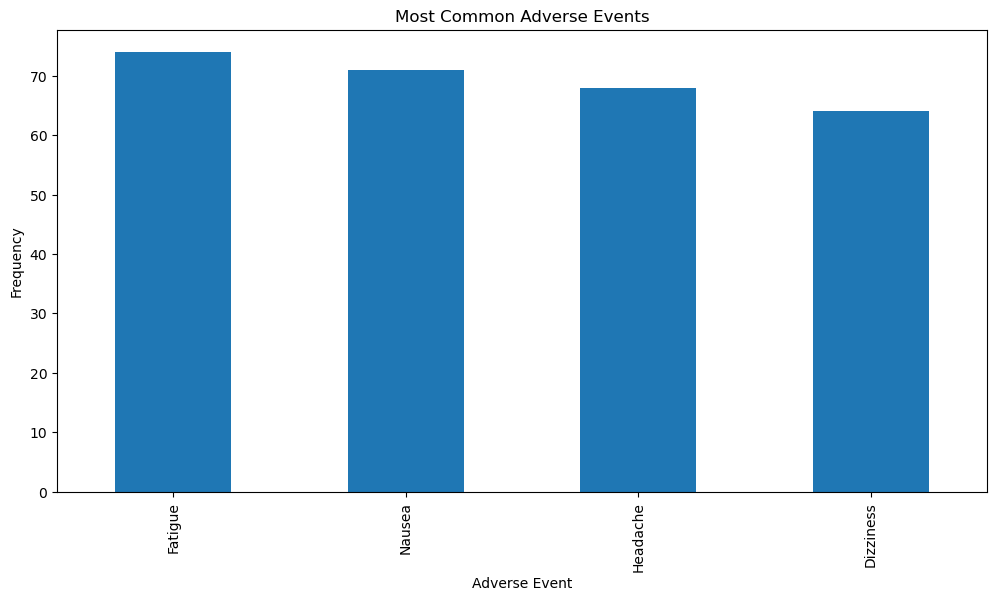

In [43]:
plt.figure(figsize=(12,6))
adverse_events.plot(kind='bar')
plt.title('Most Common Adverse Events')
plt.xlabel('Adverse Event')
plt.ylabel('Frequency')
plt.show()

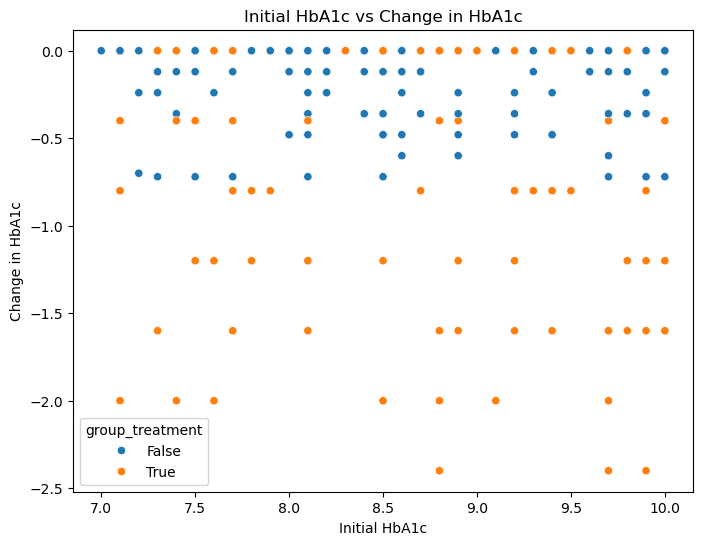

In [44]:
# Scatterplot of Initial HbA1c vs Change in HbA1c
plt.figure(figsize=(8,6))
sns.scatterplot(x='initial_hba1c', y='hba1c_change', hue='group_treatment', data=df)
plt.title('Initial HbA1c vs Change in HbA1c')
plt.xlabel('Initial HbA1c')
plt.ylabel('Change in HbA1c')
plt.show()

In [ ]:
from scipy import stats
from sklearn.linear_model import LinearRegression

In [46]:
# T-test between two groups (e.g. Treatment and Placebo)
group_0 = df[df['group_treatment'] == 0]['hba1c']
group_1 = df[df['group_treatment'] == 1]['hba1c']
t_stat, p_value = stats.ttest_ind(group_1, group_0)

In [47]:
print(f"T Test result: t-satte = {t_stat}, p-value = {p_value}")

T Test result: t-satte = -6.200485372339337, p-value = 2.0550724738165274e-09


In [48]:
# Perform ANOVA using statsmodel formua API
model = smf.ols('hba1c ~ time + group_treatment', data=df).fit()
aov_table = sm.stats.anova_lm(model, typ=2)
print(aov_table)

                     sum_sq     df          F        PR(>F)
group_treatment   43.836941    1.0  50.782549  9.143732e-12
time              64.254098    1.0  74.434639  5.169343e-16
Residual         236.524596  274.0        NaN           NaN


In [49]:
# Using chi-square test to compare adverse event rates between groups
adverse_event_table = pd.crosstab(df['group_treatment'], df['adverse_event'])
print(adverse_event_table)

adverse_event    Dizziness  Fatigue  Headache  Nausea
group_treatment                                      
False                   26       40        35      39
True                    38       34        33      32


In [50]:
# Create a contigency table for adverse events by treatment group
chi2, p, dof, expected = stats.chi2_contingency(adverse_event_table, correction=False)
print(f"Chi-square test result: chi2 = {chi2}, p-value = {p}")
print(f"Chi-square test result: dof = {dof}, expected = {expected}")

Chi-square test result: chi2 = 3.453364951919518, p-value = 0.32686108897063443
Chi-square test result: dof = 3, expected = [[32.3465704  37.40072202 34.36823105 35.88447653]
 [31.6534296  36.59927798 33.63176895 35.11552347]]


In [51]:
if 'age_group' not in df.columns:
    df['age_group'] = pd.cut(df['age'], bins=[0, 30, 60, 90], labels=['Young', 'Middle-aged', 'Old'])

In [52]:
age_groups_young = (df['age_group'] =='Young').value_counts()
print(f"Young age group:  {age_groups_young}")
print()
age_groups_Middle = (df['age_group'] =='Middle-aged').value_counts()
print("Middle aged age group: ", age_groups_Middle )

age_groups_Old = (df['age_group'] =='Old').value_counts()
print()
print(f"Old age group: : {age_groups_Old}")

Young age group:  age_group
False    277
Name: count, dtype: int64

Middle aged age group:  age_group
True     182
False     95
Name: count, dtype: int64

Old age group: : age_group
False    182
True      95
Name: count, dtype: int64


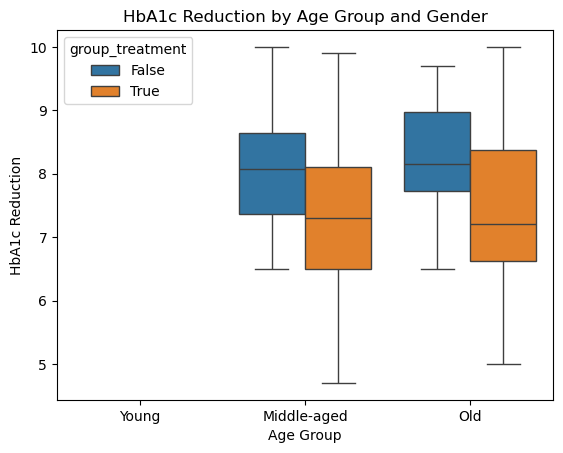

In [53]:
# Create a boxplot for HbA1c by age group and treatment group
sns.boxplot(x='age_group', y='hba1c', hue='group_treatment',  data=df)
plt.title('HbA1c Reduction by Age Group and Gender')
plt.xlabel('Age Group')
plt.ylabel('HbA1c Reduction')
plt.show()

In [54]:
df.head()

,subject_id,age,gender,duration_diabetes,initial_hba1c,hba1c,time,adverse_event,group_treatment,hba1c_change,age_group
1,2,46,Male,19,9.9,9.9,0,Fatigue,False,0.0,Middle-aged
3,4,59,Male,19,8.9,8.9,0,Headache,True,0.0,Middle-aged
6,7,69,Female,12,8.9,8.9,0,Dizziness,True,0.0,Old
7,8,44,Female,1,8.8,8.8,0,Headache,True,0.0,Middle-aged
10,11,52,Female,2,7.8,7.8,0,Nausea,True,0.0,Middle-aged


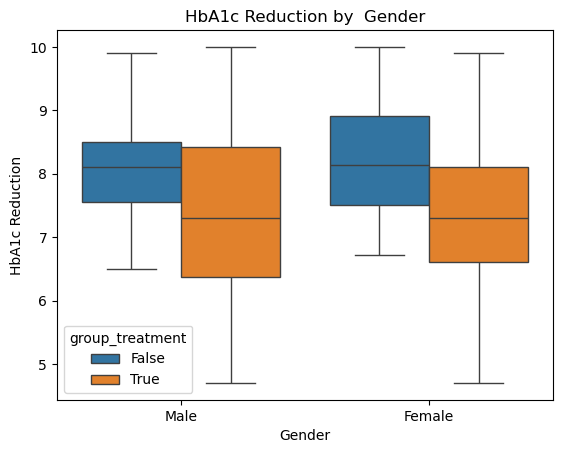

In [55]:
# Create a boxplot for HbA1c by age group and treatment group
sns.boxplot(x='gender', y='hba1c', hue='group_treatment',  data=df)
plt.title('HbA1c Reduction by  Gender')
plt.xlabel('Gender')
plt.ylabel('HbA1c Reduction')
plt.show()

In [56]:
# Calculate the correlation between duration of diabetes and HbA1c change
correlation = df['duration_diabetes'].corr(df['hba1c_change'])

In [57]:
print(f"Correlation between Duration of Diabetes and HbA1c Reduction: {correlation}")

Correlation between Duration of Diabetes and HbA1c Reduction: -0.010949212625554495
